# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name:Aung Phyo Paing



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [43]:
## Import libraries
# Data handling
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt


# Display all dataset columns
pd.set_option("display.max_columns", None)

# 1. Business Understanding
## Project Title

Student Final Grade Predictor

## Business Problem

Students who may receive low final grades are not always identified early enough. This may reduce the time available for teachers to provide academic support.

This project aims to predict a student's final grade using information about the student's study habits, attendance, family background, school support and lifestyle.

## Proposed Solution

A machine learning regression model will be developed to predict the student's final grade.

The trained model will later be deployed as a Streamlit web application. Teachers or academic advisors will enter student information, and the application will display the predicted final grade.

## Target Users

The target users are teachers, academic advisors and student support staff.

## Business Value

The solution may help schools identify students who need additional support and make more informed academic intervention decisions.

## Machine Learning Task

The target variable is `G3`, which represents the student's final grade from 0 to 20.

Since the model predicts a numerical value, this is a regression problem.

# 2. Data Understanding


## 2.1 Load dataset

In [44]:
# Read CSV file into pandas DataFrame
FILE_PATH = "student-por.csv"

df = pd.read_csv(FILE_PATH, sep=";")

# Display DataFrame
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,course,mother,1,3,1,no,no,no,yes,no,yes,yes,no,5,4,2,1,2,5,4,10,11,10
645,MS,F,18,U,LE3,T,3,1,teacher,services,course,mother,1,2,0,no,yes,no,no,yes,yes,yes,no,4,3,4,1,1,1,4,15,15,16
646,MS,F,18,U,GT3,T,1,1,other,other,course,mother,2,2,0,no,no,no,yes,yes,yes,no,no,1,1,1,1,1,5,6,11,12,9
647,MS,M,17,U,LE3,T,3,1,services,services,course,mother,2,1,0,no,no,no,no,no,yes,yes,no,2,4,5,3,4,2,6,10,10,10


In [45]:
df.shape

(649, 33)

In [46]:
# Check column names and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

### 2.1.1 Column Description

In [47]:
## Column description

column_description = pd.DataFrame({
    "Column": [
        "school", "sex", "age", "address", "famsize", "Pstatus",
        "Medu", "Fedu", "Mjob", "Fjob", "reason", "guardian",
        "traveltime", "studytime", "failures", "schoolsup", "famsup",
        "paid", "activities", "nursery", "higher", "internet",
        "romantic", "famrel", "freetime", "goout", "Dalc", "Walc",
        "health", "absences", "G1", "G2", "G3"
    ],
    "Description": [
        "Student's school",
        "Student's sex",
        "Student's age",
        "Student's home address type",
        "Family size",
        "Parents' cohabitation status",
        "Mother's education level",
        "Father's education level",
        "Mother's job",
        "Father's job",
        "Reason for choosing the school",
        "Student's guardian",
        "Home to school travel time",
        "Weekly study time",
        "Number of past class failures",
        "Extra educational support",
        "Family educational support",
        "Extra paid classes",
        "Extra-curricular activities",
        "Attended nursery school",
        "Wants to take higher education",
        "Internet access at home",
        "In a romantic relationship",
        "Quality of family relationships",
        "Free time after school",
        "Going out with friends",
        "Workday alcohol consumption",
        "Weekend alcohol consumption",
        "Current health status",
        "Number of school absences",
        "First period grade",
        "Second period grade",
        "Final grade / target variable"
    ]
})

column_description

,Column,Description
0,school,Student's school
1,sex,Student's sex
2,age,Student's age
3,address,Student's home address type
4,famsize,Family size
5,Pstatus,Parents' cohabitation status
6,Medu,Mother's education level
7,Fedu,Father's education level
8,Mjob,Mother's job
9,Fjob,Father's job


## 2.2 Summary Statistics

In [48]:
## Understand the type of variable for each column
# Summary statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,649.0,16.744222,1.218138,15.0,16.0,17.0,18.0,22.0
Medu,649.0,2.514638,1.134552,0.0,2.0,2.0,4.0,4.0
Fedu,649.0,2.306626,1.099931,0.0,1.0,2.0,3.0,4.0
traveltime,649.0,1.568567,0.748660,1.0,1.0,1.0,2.0,4.0
studytime,649.0,1.930663,0.829510,1.0,1.0,2.0,2.0,4.0
failures,649.0,0.221880,0.593235,0.0,0.0,0.0,0.0,3.0
famrel,649.0,3.930663,0.955717,1.0,4.0,4.0,5.0,5.0
freetime,649.0,3.180277,1.051093,1.0,3.0,3.0,4.0,5.0
goout,649.0,3.184900,1.175766,1.0,2.0,3.0,4.0,5.0
Dalc,649.0,1.502311,0.924834,1.0,1.0,1.0,2.0,5.0


In [49]:
# Summary statistics for categorical columns
df.describe(include="object").T

C:\Users\Aung Phyo Paing\AppData\Local\Temp\ipykernel_21820\3118575569.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
school,649,2,GP,423
sex,649,2,F,383
address,649,2,U,452
famsize,649,2,GT3,457
Pstatus,649,2,T,569
Mjob,649,5,other,258
Fjob,649,5,other,367
reason,649,4,course,285
guardian,649,3,mother,455
schoolsup,649,2,no,581


In [50]:
# Check missing values in each column
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [51]:
# Check total number of missing values
df.isnull().sum().sum()

np.int64(0)

In [52]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

### Summary Statistics Interpretation

The dataset contains both numerical and categorical columns.

For numerical columns, the summary statistics show the count, mean, standard deviation, minimum value, quartiles and maximum value. The target variable `G3` represents the final grade, with values ranging from 0 to 20.

For categorical columns, the summary statistics show the number of unique categories and the most frequent value for each column.

There are no missing values in the dataset, so no missing-value imputation is required at this stage.

The duplicate check was also performed to ensure that repeated rows do not affect the model training process.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

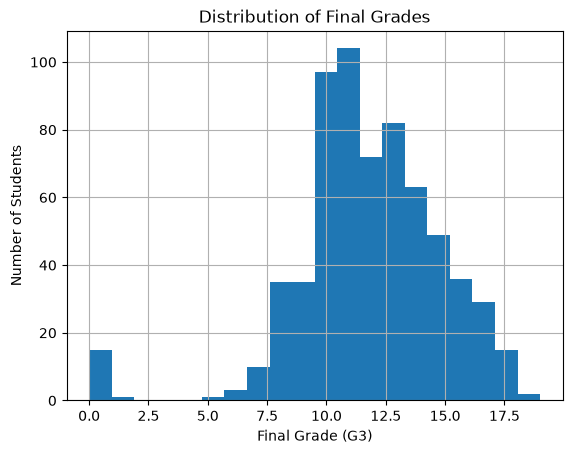

In [53]:
# Understanding distribution of target variable G3

df["G3"].hist(bins=20)

plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Grades")
plt.show()

### Target Variable Distribution Interpretation

The histogram was used to understand the distribution of the target variable `G3`, which is the student's final grade.

From the graph, most students scored around the middle range, especially between grades 10 and 14. There are fewer students at the very low and very high grade ranges.

This shows that the target variable is not evenly distributed across all grades. Since most final grades are concentrated around the middle, the model may predict middle-range grades more confidently than extreme low or high grades.


### 2.3.1.2 Understanding distribution of features

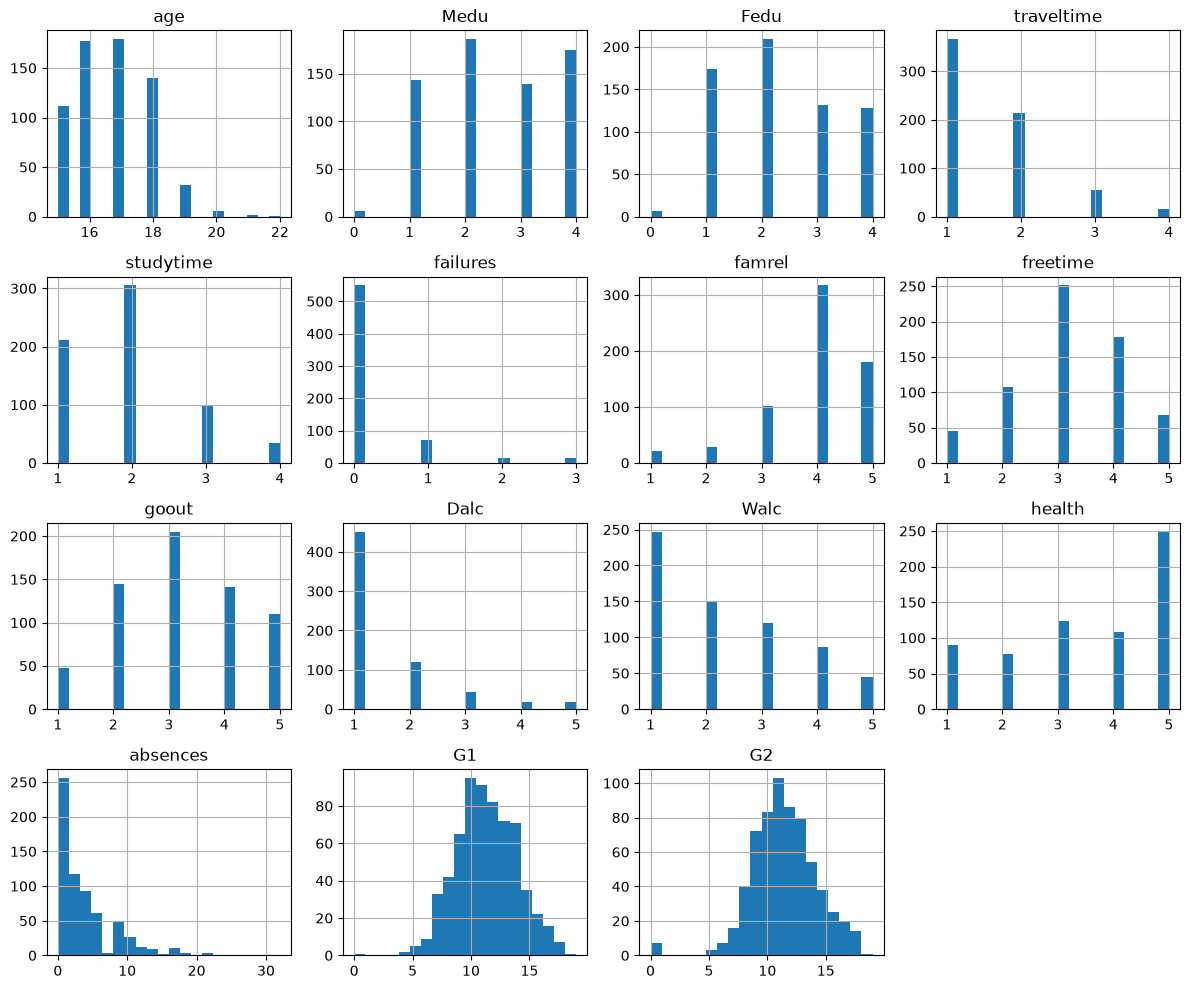

In [54]:
## Understanding distribution of numerical features

# Select all numerical features except target variable G3
numeric_features = df.select_dtypes(include=["int64", "float64"]).drop(columns=["G3"])

# Plot histograms for all numerical features
numeric_features.hist(figsize=(12, 10), bins=20)

plt.tight_layout()
plt.show()

### Numerical Feature Distribution Interpretation


From the histograms, `G1` and `G2` are mostly around the middle grade range. This shows that many students had moderate previous grades before the final grade.

For `studytime`, most students are in level 1 and level 2, so most students have low to moderate study time.

For `failures`, most students have zero past class failures. Only a small number of students have 1, 2 or 3 past failures.

For `absences`, most students have low absences, but a few students have much higher absences. This means absences is right-skewed and may contain unusual high values.

Some other numerical features, such as `Medu`, `Fedu`, `famrel`, `freetime`, `goout`, `Dalc`, `Walc`, and `health`, are mostly rating or level-based features. Their histograms help show how common each level is in the dataset.

Overall, the histograms show the spread of student grades, study habits, family background, lifestyle factors and attendance before building the prediction model.

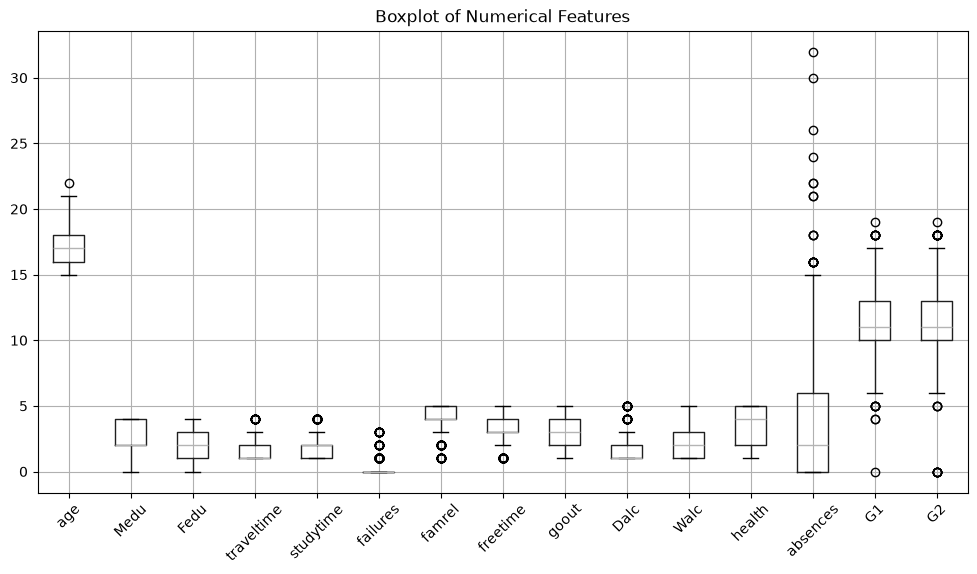

In [55]:
## Boxplot of numerical features

numeric_features.boxplot(figsize=(12, 6), rot=45)

plt.title("Boxplot of Numerical Features")
plt.show()

### Numerical Feature Boxplot Interpretation

The boxplot was used to check the spread of the numerical features and to see whether there are possible outliers.

From the boxplot, `G1` and `G2` are mostly around the middle grade range. This matches the histogram because many students have moderate previous grades.

For `studytime`, most values are in the lower levels. This shows that high study time is less common.

For `failures`, most students have zero past class failures, while higher failure values are less common.

For `absences`, there are some much higher values compared to most students. This shows that a few students were absent much more often than others, so absences has possible outliers.

Overall, the boxplot helps me see that most numerical features are within a small range, but `absences` has some unusual high values.

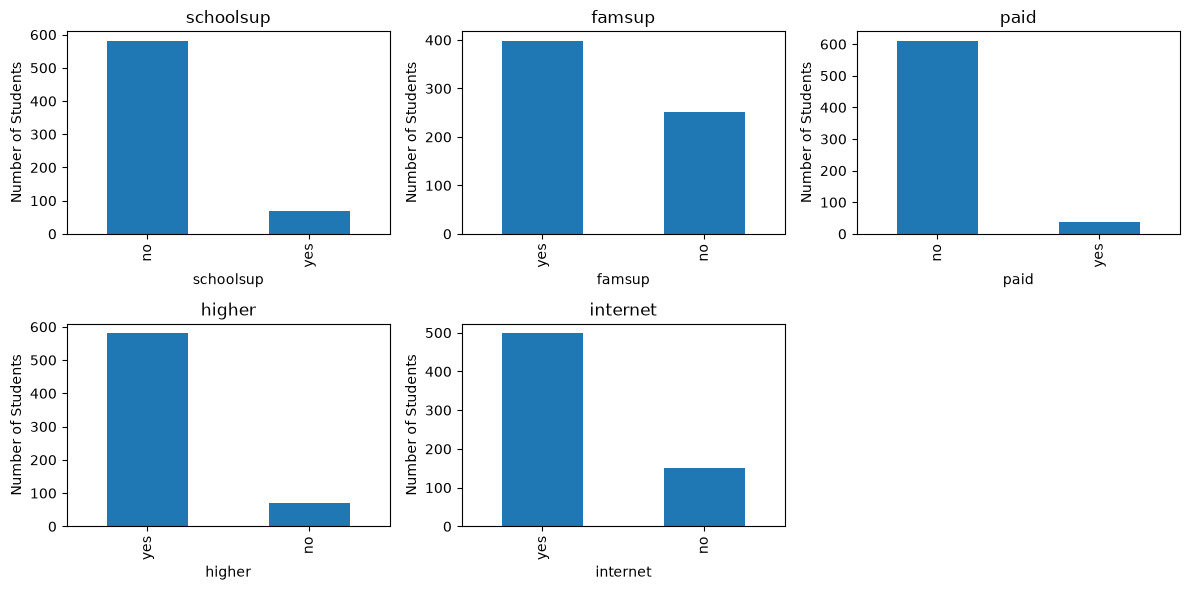

In [56]:
## Distribution of categorical features

selected_categorical = ["schoolsup", "famsup", "paid", "higher", "internet"]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for i, col in enumerate(selected_categorical):
    df[col].value_counts().plot(kind="bar", ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Number of Students")

# Hide empty subplot
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Categorical Feature Distribution Interpretation

Plotted selected categorical features that may be related to student performance, such as school support, family support, paid classes, higher education intention and internet access.

From the charts, most students do not receive extra school support. More students receive family support compared to school support. Most students also want to continue higher education and have internet access at home.

These graphs help me understand some student support and motivation-related features before converting categorical columns into numerical format for model training.

### 2.3.2 Understanding relationship between variables

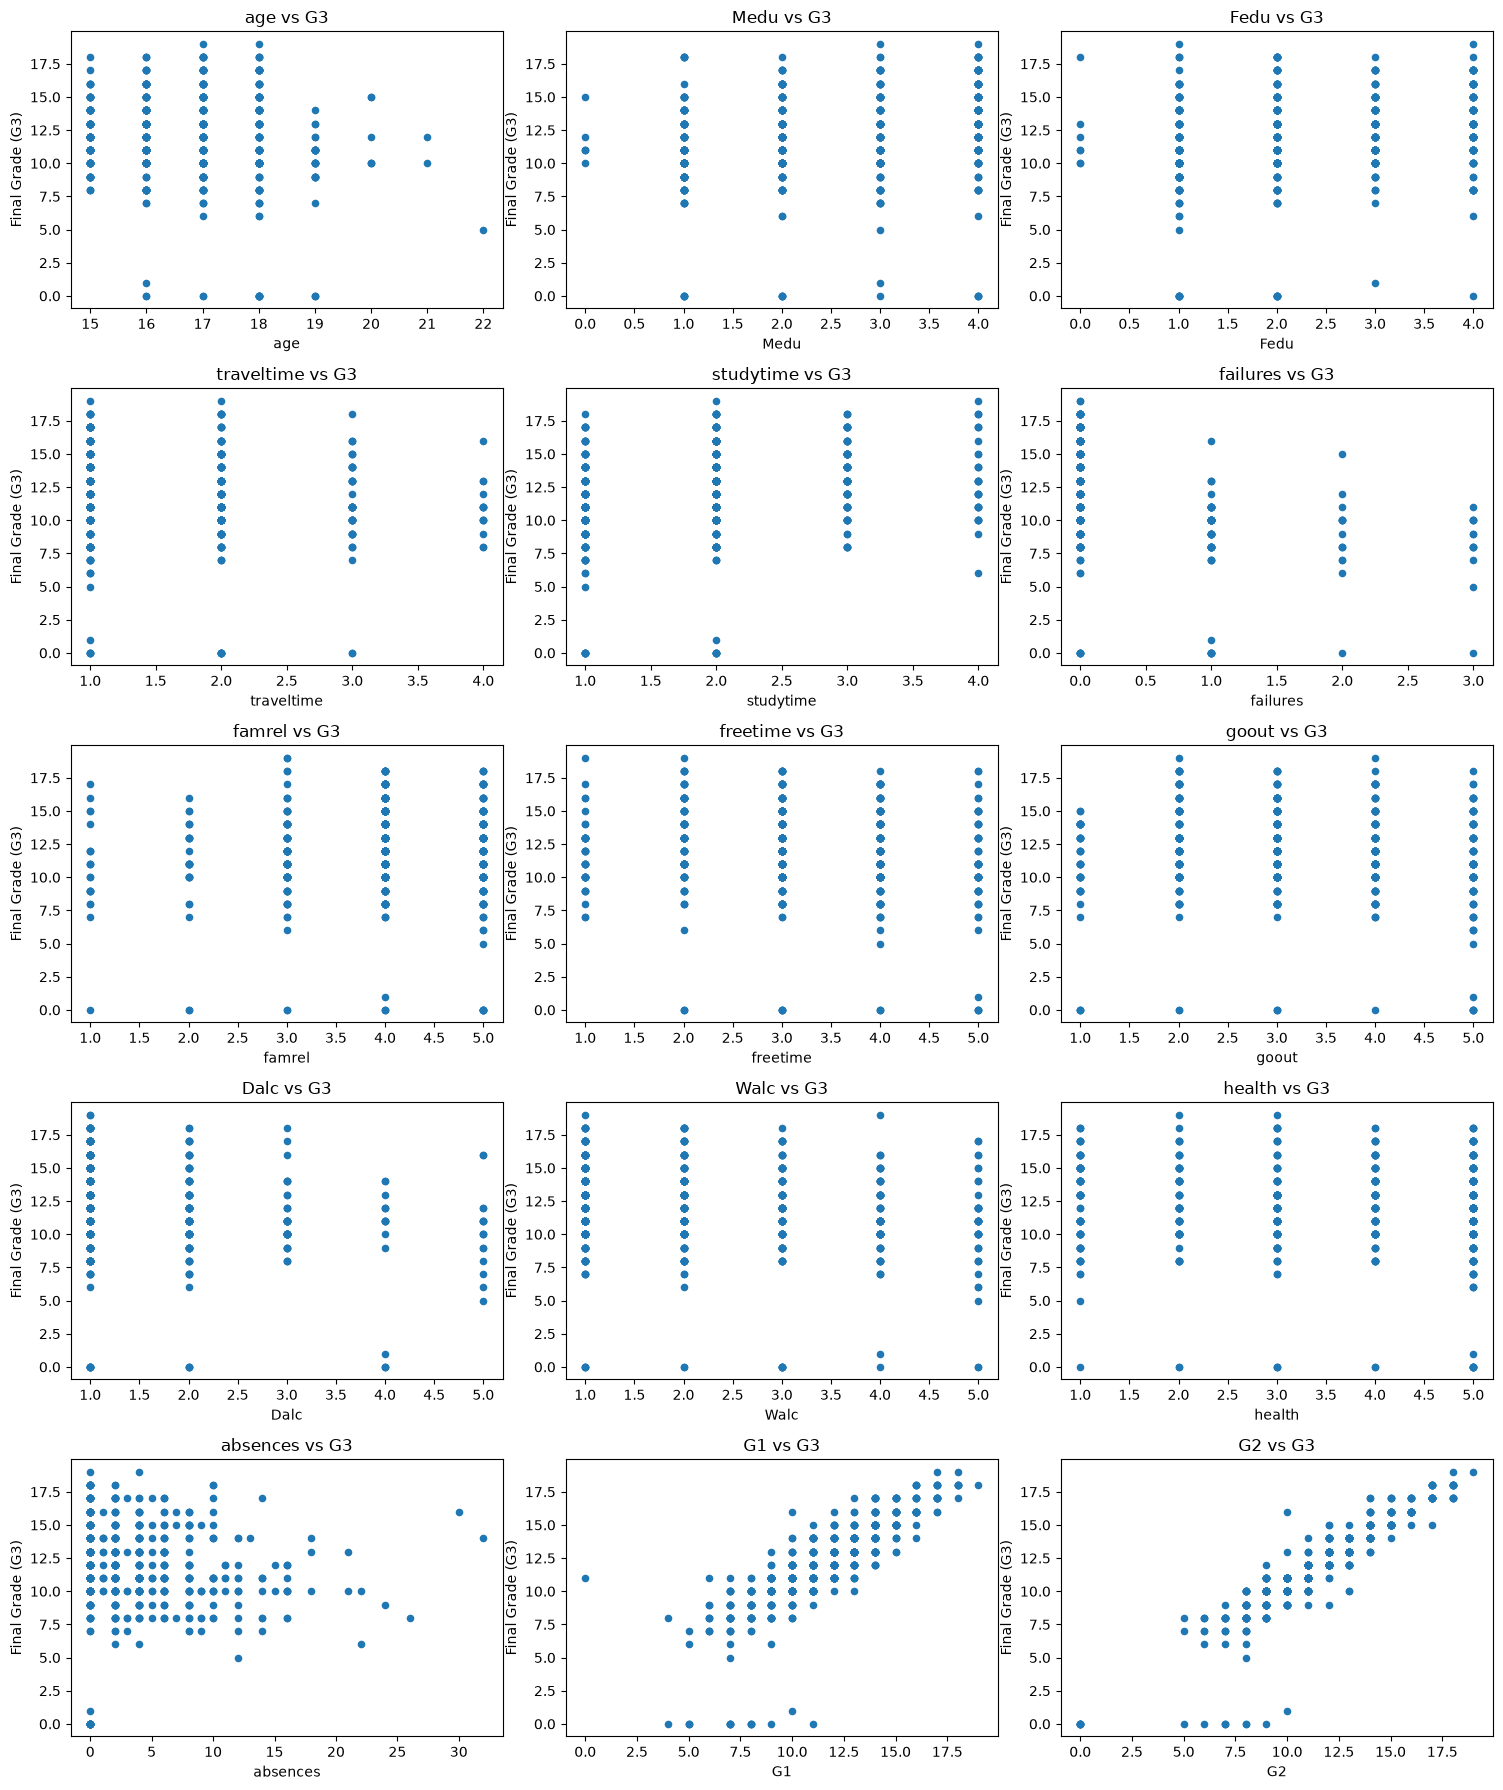

In [57]:
## Scatterplots of numerical features against G3

numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.drop("G3")

fig, axes = plt.subplots(5, 3, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    df.plot(kind="scatter", x=col, y="G3", ax=axes[i])
    axes[i].set_title(f"{col} vs G3")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Final Grade (G3)")

# Hide empty plots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

From the scatter plots, `G1` and `G2` show the clearest positive relationship with `G3`. Students with higher previous grades usually also have higher final grades.

`failures` shows a negative relationship with `G3`. Students with more past class failures usually have lower final grades.

For other numerical features such as `studytime`, `absences`, `age`, `health`, `freetime`, `goout`, `Dalc` and `Walc`, the relationship with `G3` is not very clear from the scatter plots.

Overall, the numerical relationship plots show that previous grades are the strongest visual predictors of the final grade.

C:\Users\Aung Phyo Paing\AppData\Local\Temp\ipykernel_21820\3614138717.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=["object"]).columns


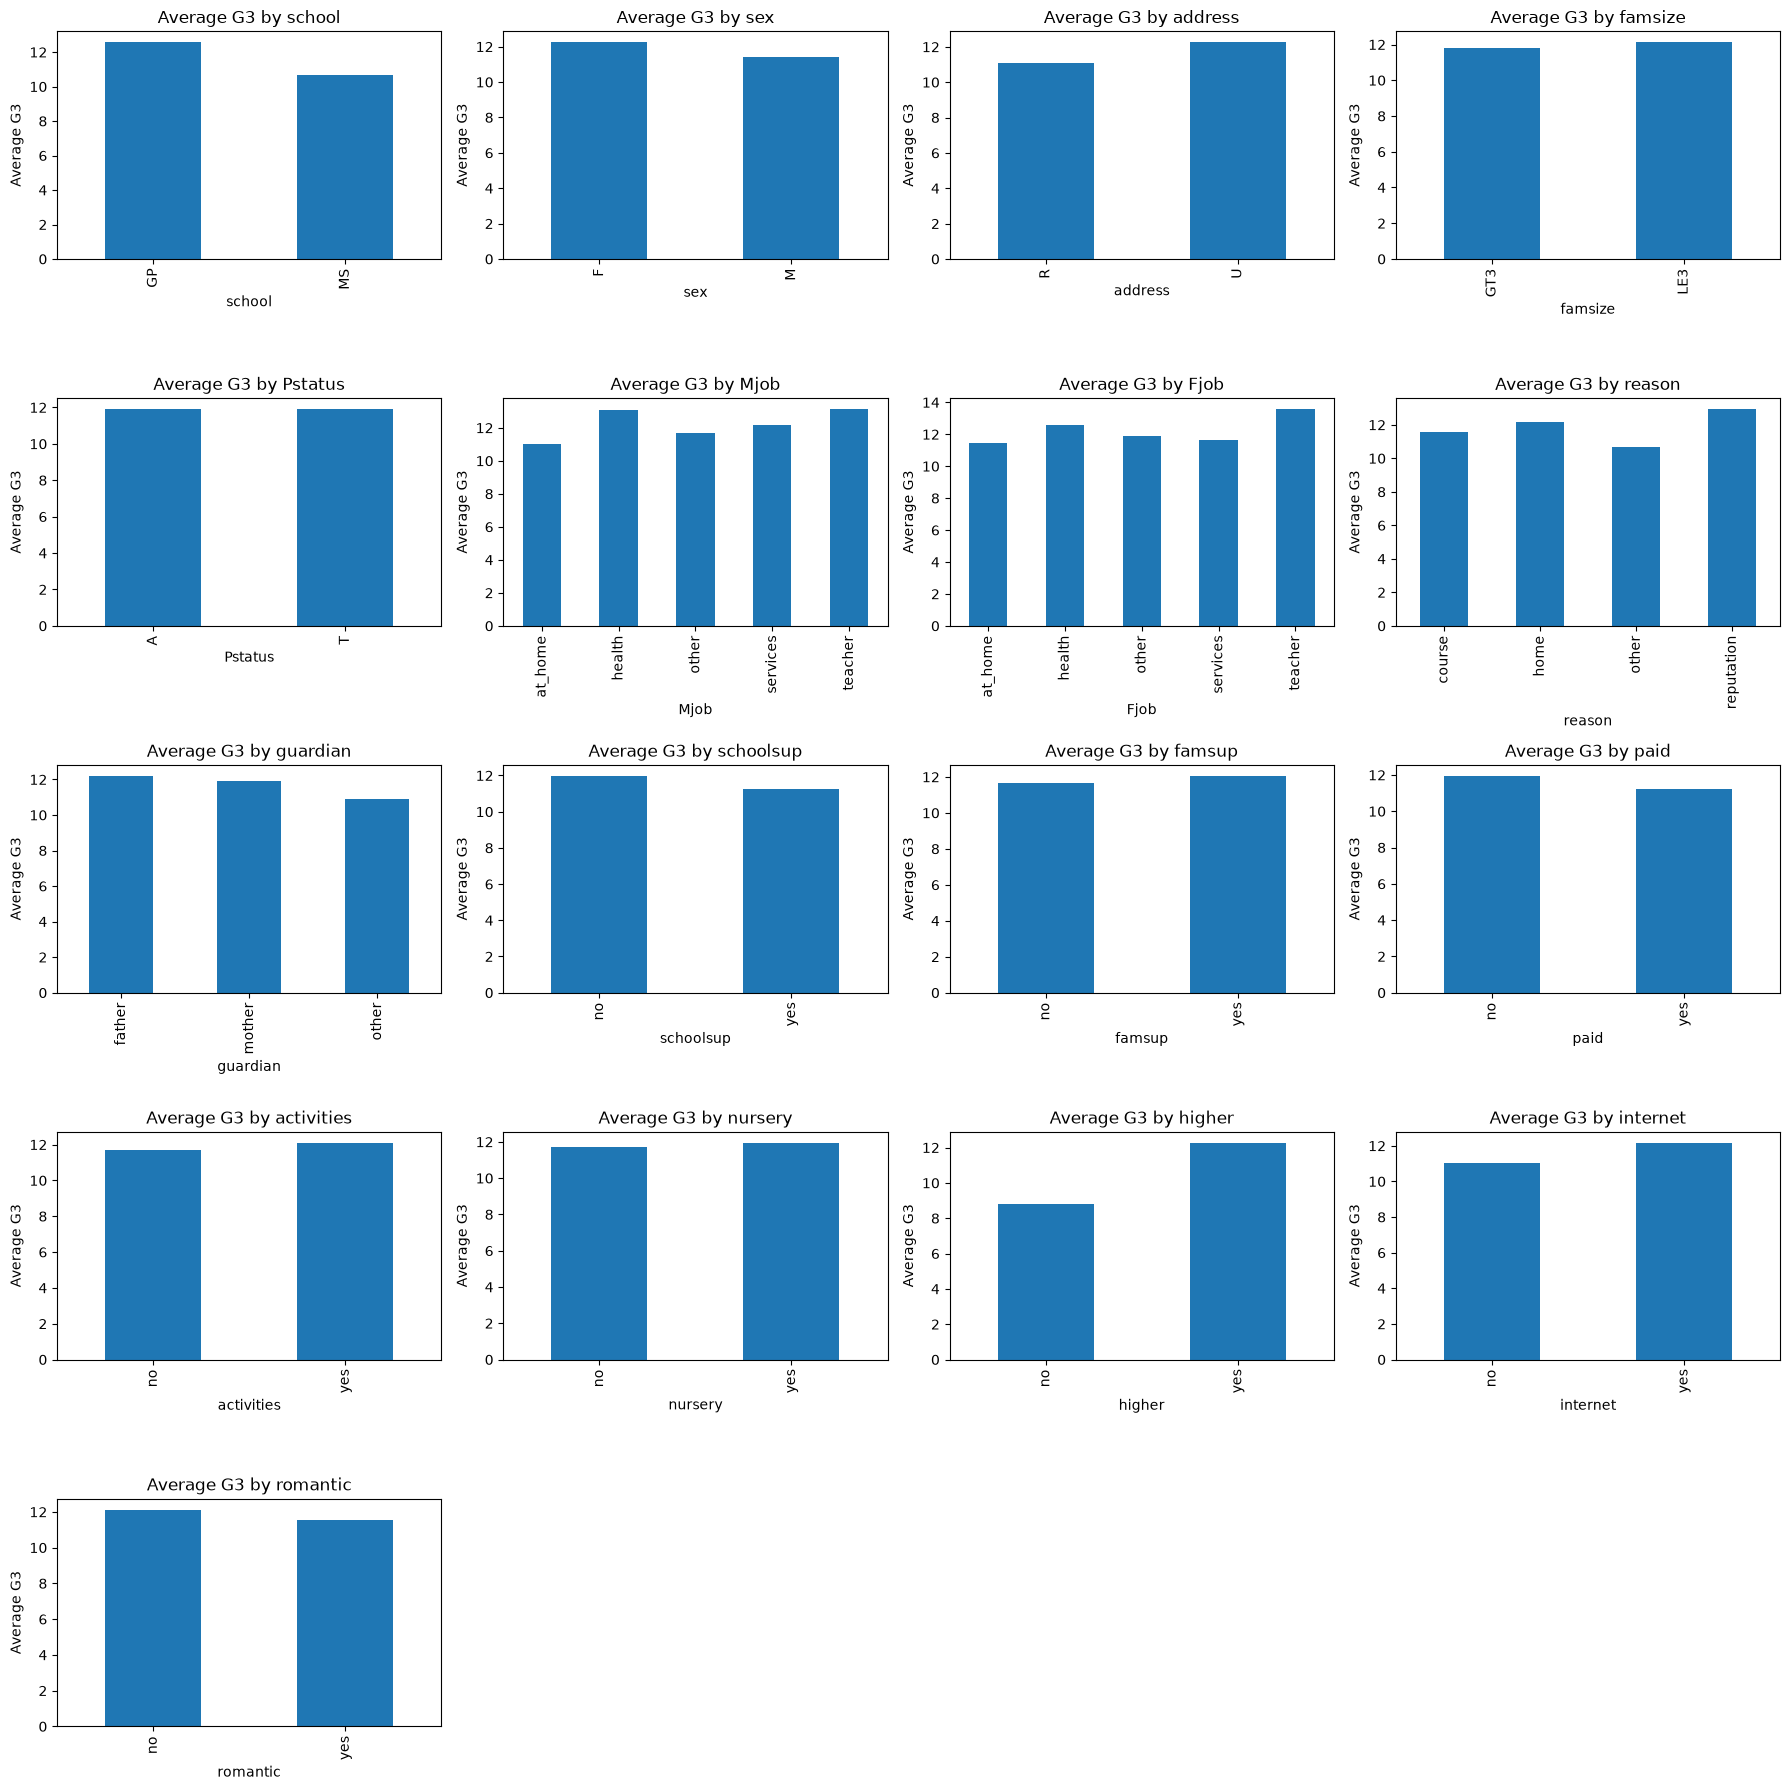

In [58]:
## Average G3 by all categorical features

categorical_features = df.select_dtypes(include=["object"]).columns

fig, axes = plt.subplots(5, 4, figsize=(18, 18))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    df.groupby(col)["G3"].mean().plot(kind="bar", ax=axes[i])
    axes[i].set_title(f"Average G3 by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Average G3")

# Hide empty plots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

For categorical features, I compared the average final grade for each category.

These charts show whether different groups of students have different average `G3` scores. For example, I can compare students with and without school support, family support, paid classes, internet access and higher education intention.

Some categories have small differences in average `G3`, but the differences are not as strong as the relationship shown by `G1` and `G2`.


In [59]:
## Check correlation between numerical features and G3

# Calculate correlation of numerical columns with target variable G3
correlation_with_g3 = df.corr(numeric_only=True)["G3"].sort_values(ascending=False)

# Display correlation values
correlation_with_g3

G3            1.000000
G2            0.918548
G1            0.826387
studytime     0.249789
Medu          0.240151
Fedu          0.211800
famrel        0.063361
goout        -0.087641
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
Walc         -0.176619
Dalc         -0.204719
failures     -0.393316
Name: G3, dtype: float64

The correlation table was used to check how each numerical feature is related to the target variable `G3`.

From the results, `G2` has the strongest positive correlation with `G3` at about 0.92. `G1` also has a strong positive correlation with `G3` at about 0.83. This means students who scored higher in previous grades usually also scored higher in the final grade.

`studytime`, `Medu`, and `Fedu` have weak positive correlations with `G3`. This means study time and parents' education may have some relationship with final grade, but the relationship is not very strong.

`failures` has the strongest negative correlation with `G3` at about -0.39. This means students with more past class failures usually have lower final grades.

Other features such as `absences`, `health`, `age`, `freetime`, `traveltime`, `Walc`, and `Dalc` have weak negative correlations with `G3`.

Overall, the correlation results show that previous grades, especially `G2` and `G1`, are the most strongly related numerical features to the final grade. However, correlation only shows relationship and does not prove direct cause.

# 3. Data Preparation

## 3.1 Data Cleaning

In [60]:
## Clean data

# Create a copy of the dataset
df_clean = df.copy()

# Check missing values
print("Total missing values:", df_clean.isnull().sum().sum())

# Check duplicate rows
print("Duplicate rows:", df_clean.duplicated().sum())

# Remove duplicate rows if any
df_clean = df_clean.drop_duplicates()

# Check shape after cleaning
print("Dataset shape after cleaning:", df_clean.shape)

Total missing values: 0
Duplicate rows: 0
Dataset shape after cleaning: (649, 33)


The dataset was copied before data preparation to avoid changing the original dataframe. Missing values and duplicate rows were checked. Since there are no missing values and no duplicate rows, no missing-value imputation or duplicate removal is required.


## 3.2 Train-Test Split

In [61]:
## Split data into train set and test set

# Define features and target
X = df_clean.drop(["G3"], axis=1)
y = df_clean["G3"]

## Check categorical columns before encoding

categorical_columns = X.select_dtypes(include=["object"]).columns

categorical_summary = pd.DataFrame({
    "Column": categorical_columns,
    "Number of Categories": [X[col].nunique() for col in categorical_columns],
    "Categories": [X[col].unique() for col in categorical_columns]
})

display(categorical_summary)

# Convert categorical columns into numeric columns using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Import train-test split
from sklearn.model_selection import train_test_split

# Split dataset into training set and testing set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display shape of train and test sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

C:\Users\Aung Phyo Paing\AppData\Local\Temp\ipykernel_21820\1370363429.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object"]).columns


,Column,Number of Categories,Categories
0,school,2,"[GP, MS]"
1,sex,2,"[F, M]"
2,address,2,"[U, R]"
3,famsize,2,"[GT3, LE3]"
4,Pstatus,2,"[A, T]"
5,Mjob,5,"[at_home, health, other, services, teacher]"
6,Fjob,5,"[teacher, other, services, health, at_home]"
7,reason,4,"[course, other, home, reputation]"
8,guardian,3,"[mother, father, other]"
9,schoolsup,2,"[yes, no]"


X_train shape: (519, 41)
X_test shape: (130, 41)
y_train shape: (519,)
y_test shape: (130,)


The target variable is `G3`, which represents the student's final grade. The feature variables are all other columns.

Categorical variables were converted into numerical format using one-hot encoding because machine learning models cannot directly process text values.

The dataset was split into 80% training data and 20% testing data. The training set is used to train the model, while the testing set is used to evaluate how well the model performs on unseen data.

# 4. Modelling

In [62]:
## Import regression models

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

### 4.2 Train Model

In [63]:
## Train regression models

# Create model objects
lr_model = LinearRegression()
dt_model = DecisionTreeRegressor(random_state=42)
rf_model = RandomForestRegressor(random_state=42)
gb_model = GradientBoostingRegressor(random_state=42)

# Train models using the training data
lr_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

Four regression models were trained using the training dataset: Linear Regression, Decision Tree Regressor, Random Forest Regressor and Gradient Boosting Regressor.

The models used `X_train` as the input features and `y_train` as the actual target values.

# 5. Model Evaluation

For this dataset, I focus more on RMSE and R2 Score.

RMSE is important because the target variable `G3` is a final grade, and large prediction errors can be serious when identifying students who may need academic support.

R2 Score is also important because it shows how well the model explains the final grade using the input features.

MAE is still used to understand the average prediction error, but RMSE and R2 Score are more useful for choosing the final model.

In [64]:
## Evaluate regression models

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Function to evaluate model performance
def evaluate_model(model_name, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    }

# Make predictions using test set
lr_pred = lr_model.predict(X_test)
dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
gb_pred = gb_model.predict(X_test)

# Baseline model predicts the average final grade
baseline_pred = np.full(len(y_test), y_train.mean())

# Store results
results = []

results.append(evaluate_model("Baseline Mean Model", y_test, baseline_pred))
results.append(evaluate_model("Linear Regression", y_test, lr_pred))
results.append(evaluate_model("Decision Tree Regressor", y_test, dt_pred))
results.append(evaluate_model("Random Forest Regressor", y_test, rf_pred))
results.append(evaluate_model("Gradient Boosting Regressor", y_test, gb_pred))

# Display results table
model_results = pd.DataFrame(results)
model_results.sort_values(by="RMSE")

,Model,MAE,MSE,RMSE,R2 Score
1,Linear Regression,0.765060,1.475909,1.214870,0.848651
3,Random Forest Regressor,0.746077,1.539812,1.240891,0.842098
4,Gradient Boosting Regressor,0.788956,1.788829,1.337471,0.816563
2,Decision Tree Regressor,0.923077,2.723077,1.650175,0.720759
0,Baseline Mean Model,2.394605,10.065329,3.172590,-0.032160


### Model Evaluation Interpretation

The models were compared using MAE, MSE, RMSE and R2 Score.

The baseline mean model performed the worst because it only predicts the average final grade and does not learn patterns from the input features.

Linear Regression achieved the lowest RMSE and the highest R2 Score. This means it made the smallest overall prediction error and explained the final grade better than the other models.

Random Forest Regressor achieved the lowest MAE, but its RMSE and R2 Score were slightly worse than Linear Regression.

Therefore, Linear Regression is the current best model based on RMSE and R2 Score. However, Random Forest Regressor and Gradient Boosting Regressor will also be tuned because they are ensemble models with several hyperparameters that can be adjusted. Random Forest also achieved the lowest MAE, so it is worth tuning to check whether its overall performance can improve.

## Iterative model development


### Further feature engineering / feature selection

### Feature Importance Analysis

In [65]:
## Feature importance using Random Forest

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
14,G2,0.827115
12,absences,0.035854
13,G1,0.019740
0,age,0.008999
7,freetime,0.008060
9,Dalc,0.007257
1,Medu,0.007206
15,school_MS,0.006518
6,famrel,0.006308
8,goout,0.006013


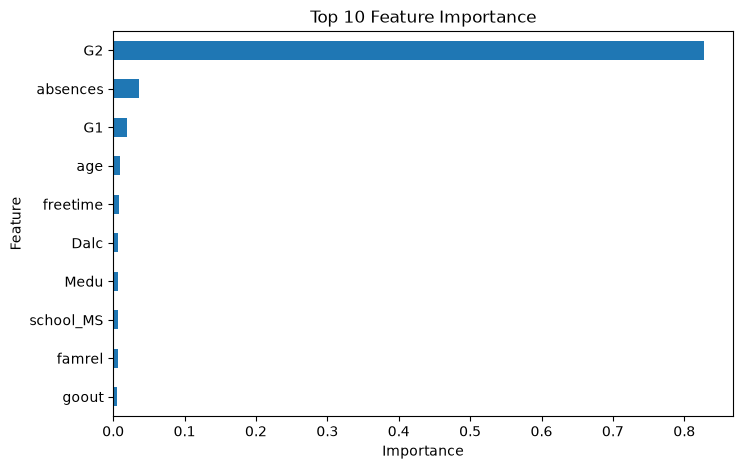

In [66]:
## Plot top 10 important features

top_10_features = feature_importance.head(10)

top_10_features.plot(
    kind="barh",
    x="Feature",
    y="Importance",
    figsize=(8, 5),
    legend=False
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance")
plt.gca().invert_yaxis()
plt.show()

### Feature Importance Interpretation

The feature importance result shows that `G2` is the most important feature for the Random Forest model. Its importance score is much higher than the other features.

This means the model depends heavily on the second period grade when predicting the final grade `G3`. 

`absences` is the second highest feature, but its importance is much smaller than `G2`. `G1` also appears in the top features, but its importance is lower because `G2` already gives very strong information about the student's performance.

Other features such as `age`, `freetime`, `Dalc`, `Medu`, `school_MS`, `famrel`, and `goout` have small importance scores.

Overall, the feature importance analysis shows that previous academic performance, especially `G2`, is the strongest factor used by the model to predict `G3`. Other numerical and encoded categorical features provide smaller additional information.

In [67]:

## Feature selection: remove G1 and G2

# Create new feature set without G1 and G2
X_without_grades = df_clean.drop(["G1", "G2", "G3"], axis=1)
y_without_grades = df_clean["G3"]

# Convert categorical columns into numeric columns using one-hot encoding
X_without_grades = pd.get_dummies(X_without_grades, drop_first=True)

# Split dataset into training set and testing set
X_train_without, X_test_without, y_train_without, y_test_without = train_test_split(
    X_without_grades,
    y_without_grades,
    test_size=0.2,
    random_state=42
)

print("X_train_without shape:", X_train_without.shape)
print("X_test_without shape:", X_test_without.shape)
print("y_train_without shape:", y_train_without.shape)
print("y_test_without shape:", y_test_without.shape)

X_train_without shape: (519, 39)
X_test_without shape: (130, 39)
y_train_without shape: (519,)
y_test_without shape: (130,)


In [68]:
## Train and evaluate models without G1 and G2

# Create model objects
lr_without_model = LinearRegression()
dt_without_model = DecisionTreeRegressor(random_state=42)
rf_without_model = RandomForestRegressor(random_state=42)
gb_without_model = GradientBoostingRegressor(random_state=42)

# Train models
lr_without_model.fit(X_train_without, y_train_without)
dt_without_model.fit(X_train_without, y_train_without)
rf_without_model.fit(X_train_without, y_train_without)
gb_without_model.fit(X_train_without, y_train_without)

# Make predictions
lr_without_pred = lr_without_model.predict(X_test_without)
dt_without_pred = dt_without_model.predict(X_test_without)
rf_without_pred = rf_without_model.predict(X_test_without)
gb_without_pred = gb_without_model.predict(X_test_without)

# Store results
without_grades_results = []

without_grades_results.append(evaluate_model("Linear Regression without G1/G2", y_test_without, lr_without_pred))
without_grades_results.append(evaluate_model("Decision Tree without G1/G2", y_test_without, dt_without_pred))
without_grades_results.append(evaluate_model("Random Forest without G1/G2", y_test_without, rf_without_pred))
without_grades_results.append(evaluate_model("Gradient Boosting without G1/G2", y_test_without, gb_without_pred))

# Display results
without_grades_results = pd.DataFrame(without_grades_results)
without_grades_results.sort_values(by="RMSE")

,Model,MAE,MSE,RMSE,R2 Score
3,Gradient Boosting without G1/G2,2.054075,7.584223,2.753947,0.222268
2,Random Forest without G1/G2,2.061846,8.037420,2.835034,0.175794
0,Linear Regression without G1/G2,2.156382,8.189784,2.861780,0.160170
1,Decision Tree without G1/G2,2.715385,13.500000,3.674235,-0.384372


In [69]:
## Tune Gradient Boosting and Random Forest without G1 and G2

from sklearn.model_selection import RandomizedSearchCV

# Tune Gradient Boosting
param_dist_gb_without = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 5],
    "min_samples_split": [2, 5, 10]
}

gb_without_tuning = GradientBoostingRegressor(random_state=42)

rs_gb_without = RandomizedSearchCV(
    estimator=gb_without_tuning,
    param_distributions=param_dist_gb_without,
    n_iter=10,
    cv=5,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

rs_gb_without.fit(X_train_without, y_train_without)

print("Best Gradient Boosting parameters without G1/G2:")
print(rs_gb_without.best_params_)


# Tune Random Forest
param_dist_rf_without = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_without_tuning = RandomForestRegressor(random_state=42)

rs_rf_without = RandomizedSearchCV(
    estimator=rf_without_tuning,
    param_distributions=param_dist_rf_without,
    n_iter=10,
    cv=5,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

rs_rf_without.fit(X_train_without, y_train_without)

print("Best Random Forest parameters without G1/G2:")
print(rs_rf_without.best_params_)

Best Gradient Boosting parameters without G1/G2:
{'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 2, 'learning_rate': 0.05}
Best Random Forest parameters without G1/G2:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}


In [70]:
## Evaluate tuned models without G1 and G2

# Get best tuned models
best_gb_without = rs_gb_without.best_estimator_
best_rf_without = rs_rf_without.best_estimator_

# Make predictions
tuned_gb_without_pred = best_gb_without.predict(X_test_without)
tuned_rf_without_pred = best_rf_without.predict(X_test_without)

# Evaluate tuned models
tuned_without_results = []

tuned_without_results.append(
    evaluate_model("Tuned Gradient Boosting without G1/G2", y_test_without, tuned_gb_without_pred)
)

tuned_without_results.append(
    evaluate_model("Tuned Random Forest without G1/G2", y_test_without, tuned_rf_without_pred)
)

# Combine normal without-grade models and tuned without-grade models
normal_without_results_df = pd.DataFrame(without_grades_results)
tuned_without_results_df = pd.DataFrame(tuned_without_results)

final_without_grades_results = pd.concat(
    [normal_without_results_df, tuned_without_results_df],
    ignore_index=True
)

# Display comparison
final_without_grades_results.sort_values(by="RMSE")

,Model,MAE,MSE,RMSE,R2 Score
3,Gradient Boosting without G1/G2,2.054075,7.584223,2.753947,0.222268
5,Tuned Random Forest without G1/G2,2.024232,7.844870,2.800869,0.195540
4,Tuned Gradient Boosting without G1/G2,2.082771,7.907797,2.812080,0.189087
2,Random Forest without G1/G2,2.061846,8.037420,2.835034,0.175794
0,Linear Regression without G1/G2,2.156382,8.189784,2.861780,0.160170
1,Decision Tree without G1/G2,2.715385,13.500000,3.674235,-0.384372


### Model Interpretation without G1 and G2

The models were tested again without using `G1` and `G2` to check whether it is possible to predict final grades earlier, before previous grades are available.

The best model without `G1` and `G2` was Gradient Boosting Regressor, with an RMSE of about 2.75. After tuning Random Forest and Gradient Boosting, the tuned models did not improve the result.

This shows that the model can still make some predictions using other student information, but the performance is much weaker compared to the full model with `G1` and `G2`.

From a business point of view, the model without `G1` and `G2` could be used as an early-warning model before previous grades are available. However, it is less accurate. The full model with `G1` and `G2` is still better for final grade prediction because previous grades provide much stronger information.

## Hyperparameter Tuning

#### Decision After Testing Without G1 and G2

The model without `G1` and `G2` was tested to check whether early prediction is possible before previous grades are available.

The results show that prediction is possible, but the performance is much weaker than the model using all features. Even after tuning, the models without `G1` and `G2` did not perform better.

Therefore, I decided to continue with the original full feature set, including `G1` and `G2`, for the final model development and hyperparameter tuning. This is because the full feature set gives better prediction performance for `G3`.

I tuned Random Forest and Gradient Boosting because they are stronger candidate models and have more hyperparameters to adjust.


In [71]:
## Hyperparameter tuning for Random Forest Regressor

from sklearn.model_selection import RandomizedSearchCV

# Define hyperparameter values
param_dist_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# Create Random Forest model
rf_tuning_model = RandomForestRegressor(random_state=42)

# Create RandomizedSearchCV object
rs_rf = RandomizedSearchCV(
    estimator=rf_tuning_model,
    param_distributions=param_dist_rf,
    n_iter=10,
    cv=5,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

# Fit RandomizedSearchCV
rs_rf.fit(X_train, y_train)

# Display best parameters
print("Best parameters:")
print(rs_rf.best_params_)

Best parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}


In [72]:
## Hyperparameter tuning for Gradient Boosting Regressor

# Define hyperparameter values
param_dist_gb = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 5],
    "min_samples_split": [2, 5, 10]
}

# Create Gradient Boosting model
gb_tuning_model = GradientBoostingRegressor(random_state=42)

# Create RandomizedSearchCV object
rs_gb = RandomizedSearchCV(
    estimator=gb_tuning_model,
    param_distributions=param_dist_gb,
    n_iter=10,
    cv=5,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

# Fit RandomizedSearchCV
rs_gb.fit(X_train, y_train)

# Display best parameters
print("Best parameters for Gradient Boosting:")
print(rs_gb.best_params_)

Best parameters for Gradient Boosting:
{'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 2, 'learning_rate': 0.05}


In [73]:
## Evaluate tuned Random Forest and Gradient Boosting models

# Get best tuned models
best_rf_model = rs_rf.best_estimator_
best_gb_model = rs_gb.best_estimator_

# Make predictions
tuned_rf_pred = best_rf_model.predict(X_test)
tuned_gb_pred = best_gb_model.predict(X_test)

# Evaluate tuned models
tuned_rf_result = evaluate_model("Tuned Random Forest Regressor", y_test, tuned_rf_pred)
tuned_gb_result = evaluate_model("Tuned Gradient Boosting Regressor", y_test, tuned_gb_pred)

# Add tuned model results to original model results
updated_model_results = pd.concat(
    [
        model_results,
        pd.DataFrame([tuned_rf_result]),
        pd.DataFrame([tuned_gb_result])
    ],
    ignore_index=True
)

# Display updated results
updated_model_results.sort_values(by="RMSE")

,Model,MAE,MSE,RMSE,R2 Score
1,Linear Regression,0.765060,1.475909,1.214870,0.848651
6,Tuned Gradient Boosting Regressor,0.721287,1.518308,1.232196,0.844304
3,Random Forest Regressor,0.746077,1.539812,1.240891,0.842098
4,Gradient Boosting Regressor,0.788956,1.788829,1.337471,0.816563
5,Tuned Random Forest Regressor,0.941765,2.119423,1.455824,0.782662
2,Decision Tree Regressor,0.923077,2.723077,1.650175,0.720759
0,Baseline Mean Model,2.394605,10.065329,3.172590,-0.032160


### Hyperparameter Tuning Interpretation

RandomizedSearchCV was used to tune Random Forest Regressor and Gradient Boosting Regressor.

The tuned Gradient Boosting Regressor improved compared to the original Gradient Boosting Regressor. Its RMSE became lower and its R2 Score became higher.

However, Linear Regression still achieved the lowest RMSE and highest R2 Score overall.

The tuned Random Forest Regressor did not improve compared to the original Random Forest Regressor.

Therefore, Linear Regression is selected as the final model because it has the best overall performance based on RMSE and R2 Score.

### Final Model Selection and Export

Linear Regression was selected as the final model.

After comparing the original models and tuned models, Linear Regression still had the lowest RMSE and highest R2 Score. This means it gave the best overall performance for predicting `G3`.


In [74]:
## Save final model

import joblib

# Select final model
final_model = lr_model

# Save final model
joblib.dump(final_model, "student_grade_model.pkl")



['student_grade_model.pkl']

In [75]:
## Load saved model and test prediction

# Load saved model
loaded_model = joblib.load("student_grade_model.pkl")

# Test prediction using first 5 rows from X_test
test_predictions = loaded_model.predict(X_test.head(5))

print("Loaded model predictions:")
print(test_predictions)

Loaded model predictions:
[18.40265613 11.82720849 18.56288575 10.80969554 11.74323992]



The final Linear Regression model was saved using `joblib.dump()` and loaded again using `joblib.load()`.

The loaded model was tested using sample rows from `X_test`, and it successfully produced predictions. This confirms that the saved model file can be reused later in the Streamlit web application.

In [76]:
## Load saved model and compare predictions with original dataset

# Load saved model
loaded_model = joblib.load("student_grade_model.pkl")

# Select 5 test rows
sample_X = X_test.head(5)

# Predict using the saved model
sample_predictions = loaded_model.predict(sample_X)

# Get the same rows from the original cleaned dataset
prediction_check = df_clean.loc[sample_X.index].copy()

# Add predicted G3 and error
prediction_check["Predicted_G3"] = sample_predictions
prediction_check["Error"] = prediction_check["G3"] - prediction_check["Predicted_G3"]

# Show important columns only
prediction_check[["G1", "G2", "studytime", "failures", "absences", "G3", "Predicted_G3", "Error"]]

,G1,G2,studytime,failures,absences,G3,Predicted_G3,Error
636,17,18,2,0,4,19,18.402656,0.597344
220,11,11,2,0,2,12,11.827208,0.172792
594,18,18,2,0,0,18,18.562886,-0.562886
429,10,11,2,0,5,11,10.809696,0.190304
72,13,11,2,0,2,11,11.743240,-0.743240
